# NB01 — Threshold Derivation via Weighted Classifier

**Project**: `fitness_browser_stubborn_set`

**Goal**: Fit a weighted classifier to BERDL-native evidence features such that:
- **Recall** ≥ 90% on the 1,762 reannotated set, AND
- **Stubborn candidate pool** < 10,000 genes (non-reannotated in the candidate pool).

We try three approaches:
1. Simple counting baseline (C1 + C2 + C3 with unit weights).
2. Logistic regression on 6 continuous features with `class_weight='balanced'`.
3. Hand-tuned compound rules around the tradeoff frontier.

We operate on the local parquet extract produced by `00_extract_gene_features.py` —
run that script first to refresh from BERDL.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

REPO_ROOT = Path.cwd().resolve()
while REPO_ROOT.name and not (REPO_ROOT / ".venv-berdl").exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
PROJECT_DIR = REPO_ROOT / "projects" / "fitness_browser_stubborn_set"
DATA_DIR = PROJECT_DIR / "data"
FIG_DIR = PROJECT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

FEATURES_PATH = DATA_DIR / "gene_evidence_features.parquet"
assert FEATURES_PATH.exists(), "Run notebooks/00_extract_gene_features.py first"

df_all = pd.read_parquet(FEATURES_PATH)
print(f"Loaded {len(df_all):,} FB genes × {len(df_all.columns)} columns (all 48 orgs)")

# Restrict to the organisms where curators have actually produced any reannotation.
# Orgs with zero reannotations may simply be uncurated — not "left alone after review".
# Scoping the analysis to the curated orgs keeps the comparison apples-to-apples.
curated_orgs = sorted(df_all.loc[df_all.is_reannotated == 1, "orgId"].unique())
print(f"\nCurated organisms (any reannotation): {len(curated_orgs)}")

df = df_all[df_all["orgId"].isin(curated_orgs)].copy()
n_dropped = len(df_all) - len(df)
print(f"After restriction: {len(df):,} genes  (dropped {n_dropped:,} from {48 - len(curated_orgs)} uncurated orgs)")
print(df.dtypes.to_string())

Loaded 182,447 FB genes × 11 columns (all 48 orgs)

Curated organisms (any reannotation): 35
After restriction: 139,527 genes  (dropped 42,920 from 13 uncurated orgs)
orgId                         str
locusId                       str
max_abs_fit               float64
max_abs_t                 float64
n_strong_experiments        int64
n_moderate_experiments      int64
in_specificphenotype        int32
max_cofit                 float64
is_reannotated              int32
gene_symbol                   str
gene_desc                     str


## 1. Reannotation set + dual target

In [2]:
TARGET_RECALL = 0.90
TARGET_MAX_STUBBORN = 10_000

n_reann = int(df["is_reannotated"].sum())
n_other = int(len(df) - n_reann)
print(f"Reannotated (with fitness data): {n_reann}")
print(f"Non-reannotated:                {n_other:,}")
print(f"Dual target: recall >= {TARGET_RECALL*100:.0f}% AND stubborn < {TARGET_MAX_STUBBORN:,}")

Reannotated (with fitness data): 1729
Non-reannotated:                137,798
Dual target: recall >= 90% AND stubborn < 10,000


## 2. Evidence features + derived features

The raw extract has 6 numeric features per gene. We also add a few derived features
for the classifier (log-compressed counts, clipped magnitudes) so the logistic
regression doesn't get dominated by the count scales.

In [3]:
FEATURES = [
    "in_specificphenotype",
    "max_abs_fit",
    "max_abs_t",
    "n_strong_experiments",
    "n_moderate_experiments",
    "max_cofit",
]
# Clip + log compress — robust to heavy tails
X = pd.DataFrame({
    "in_specificphenotype": df["in_specificphenotype"].astype(float),
    "max_abs_fit":           np.clip(df["max_abs_fit"], 0, 8),
    "max_abs_t":             np.clip(df["max_abs_t"], 0, 20),
    "log_n_strong":          np.log1p(df["n_strong_experiments"]),
    "log_n_moderate":        np.log1p(df["n_moderate_experiments"]),
    "max_cofit":             df["max_cofit"].astype(float),
})
y = df["is_reannotated"].astype(int).values
print(X.describe().round(3).to_string())

       in_specificphenotype  max_abs_fit   max_abs_t  log_n_strong  log_n_moderate   max_cofit
count            139527.000   139527.000  139527.000    139527.000      139527.000  139527.000
mean                  0.102        1.556       4.755         0.276           0.448       0.532
std                   0.302        1.509       4.025         0.782           1.000       0.181
min                   0.000        0.079       0.773         0.000           0.000       0.161
25%                   0.000        0.593       2.507         0.000           0.000       0.395
50%                   0.000        0.959       3.147         0.000           0.000       0.483
75%                   0.000        1.866       4.958         0.000           0.000       0.640
max                   1.000        8.000      20.000         6.073           6.136       0.999


## 3. Helper — recall / pool-size scan for any score

In [4]:
def operating_points(scores: np.ndarray, y: np.ndarray) -> pd.DataFrame:
    """For a continuous score, compute recall and stubborn size at every threshold
    where scores change (uses unique scores descending)."""
    order = np.argsort(-scores)
    sorted_scores = scores[order]
    sorted_y = y[order]
    # Cumulative counts as we lower the threshold (include more)
    cum_reann = np.cumsum(sorted_y)
    cum_other = np.cumsum(1 - sorted_y)
    total_reann = sorted_y.sum()
    # Unique thresholds (on boundaries)
    boundaries = np.concatenate([[True], sorted_scores[1:] != sorted_scores[:-1]])
    # we want the point AT each score-value (genes with score >= v)
    idx = np.where(boundaries)[0]
    # For each boundary, the count of genes with score >= this value is idx+1 ... but we want the
    # LAST index where score == this value. Use:
    last_idx_per_group = np.concatenate([idx[1:] - 1, [len(sorted_scores) - 1]])
    thresholds = sorted_scores[idx]
    reann_at = cum_reann[last_idx_per_group]
    other_at = cum_other[last_idx_per_group]
    recall = reann_at / total_reann
    return pd.DataFrame({
        "threshold": thresholds,
        "reann_at_or_above": reann_at,
        "stubborn_at_or_above": other_at,
        "pool_size": reann_at + other_at,
        "recall": recall,
    })


def pick_target(ops: pd.DataFrame, min_recall: float, max_stubborn: int) -> dict:
    """Return smallest-pool operating point meeting both targets, else the best-effort
    frontier point closest to the target."""
    feasible = ops[(ops["recall"] >= min_recall) & (ops["stubborn_at_or_above"] <= max_stubborn)]
    if len(feasible) > 0:
        best = feasible.sort_values("stubborn_at_or_above").iloc[0]
        return {"feasible": True, **best.to_dict()}
    # Nearest point: the lowest-stubborn point that still meets recall
    recall_ok = ops[ops["recall"] >= min_recall]
    if len(recall_ok) > 0:
        best = recall_ok.sort_values("stubborn_at_or_above").iloc[0]
        return {"feasible": False, **best.to_dict()}
    # Recall target not met anywhere
    best = ops.sort_values("recall", ascending=False).iloc[0]
    return {"feasible": False, **best.to_dict()}

## 4. Baseline — simple counting score (C1 + C2 + C3)

In [5]:
df["C1_specific"] = df["in_specificphenotype"].astype(int)
df["C2_strong"]   = (df["n_strong_experiments"] >= 1).astype(int)
df["C3_cofit"]    = (df["max_cofit"] >= 0.75).astype(int)
df["count_score"] = df["C1_specific"] + df["C2_strong"] + df["C3_cofit"]

count_ops = operating_points(df["count_score"].values.astype(float), y)
print("Counting classifier (integer score 0-3):")
print(count_ops.to_string(index=False))
count_pick = pick_target(count_ops, TARGET_RECALL, TARGET_MAX_STUBBORN)
print(f"\nTarget hit by counting rule? {count_pick['feasible']}")
print(f"Best operating point: threshold >= {count_pick['threshold']:.0f}, "
      f"recall={count_pick['recall']*100:.1f}%, stubborn={int(count_pick['stubborn_at_or_above']):,}")

Counting classifier (integer score 0-3):
 threshold  reann_at_or_above  stubborn_at_or_above  pool_size   recall
       3.0                828                  3450       4278 0.478890
       2.0               1477                 16326      17803 0.854251
       1.0               1667                 32533      34200 0.964141
       0.0               1729                137798     139527 1.000000

Target hit by counting rule? False
Best operating point: threshold >= 1, recall=96.4%, stubborn=32,533


## 5. Logistic regression on continuous features

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X.values)

logit = LogisticRegression(class_weight="balanced", max_iter=2000, random_state=0)
logit.fit(X_scaled, y)

weights = pd.Series(logit.coef_[0], index=X.columns).sort_values(key=abs, ascending=False)
print("Logistic regression weights (scaled features):")
print(weights.round(3).to_string())
print(f"Intercept: {logit.intercept_[0]:.3f}")

# Predicted probability of being reannotated
probas = logit.predict_proba(X_scaled)[:, 1]
df["logit_score"] = probas

logit_ops = operating_points(probas, y)
logit_pick = pick_target(logit_ops, TARGET_RECALL, TARGET_MAX_STUBBORN)
print(f"\nDual target hit by logistic regression? {logit_pick['feasible']}")
print(f"Best operating point: proba >= {logit_pick['threshold']:.4f}, "
      f"recall={logit_pick['recall']*100:.1f}%, "
      f"pool={int(logit_pick['pool_size']):,}, stubborn={int(logit_pick['stubborn_at_or_above']):,}")

Logistic regression weights (scaled features):
in_specificphenotype    0.978
max_abs_fit             0.887
max_cofit               0.683
log_n_strong            0.224
log_n_moderate         -0.210
max_abs_t              -0.080
Intercept: -2.282

Dual target hit by logistic regression? False
Best operating point: proba >= 0.5319, recall=90.1%, pool=19,689, stubborn=18,132


## 6. Hand-tuned compound rules

A small set of compound rules built from raw thresholds. Useful sanity checks — if
logistic regression is close to any of these, it means the signal is really that
simple.

In [7]:
rules = {
    "C1 or C2 or cofit>=0.85":            (df.C1_specific == 1) | (df.C2_strong == 1) | (df.max_cofit >= 0.85),
    "C1 or (C2 and cofit>=0.85)":         (df.C1_specific == 1) | ((df.C2_strong == 1) & (df.max_cofit >= 0.85)),
    "C1 or (|fit|>=2 and cofit>=0.80)":   (df.C1_specific == 1) | ((df.max_abs_fit >= 2) & (df.max_cofit >= 0.80)),
    "C1 or (n_strong>=2)":                (df.C1_specific == 1) | (df.n_strong_experiments >= 2),
    "C1 or (n_strong>=2 and cofit>=0.80)":(df.C1_specific == 1) | ((df.n_strong_experiments >= 2) & (df.max_cofit >= 0.80)),
    "(C1 or n_strong>=3) or cofit>=0.85": (df.C1_specific == 1) | (df.n_strong_experiments >= 3) | (df.max_cofit >= 0.85),
    "C1 and n_moderate>=3":               (df.C1_specific == 1) & (df.n_moderate_experiments >= 3),
    "|fit|>=3 or cofit>=0.90":            (df.max_abs_fit >= 3) | (df.max_cofit >= 0.90),
}

rule_results = []
for name, mask in rules.items():
    rr = int((mask & (df.is_reannotated == 1)).sum())
    ro = int((mask & (df.is_reannotated == 0)).sum())
    rule_results.append({
        "rule": name,
        "pool": rr + ro,
        "reann": rr,
        "stubborn": ro,
        "recall_pct": round(rr / n_reann * 100, 1),
        "hits_target": (rr / n_reann >= TARGET_RECALL) and (ro <= TARGET_MAX_STUBBORN),
    })
rule_df = pd.DataFrame(rule_results).sort_values("stubborn")
print(rule_df.to_string(index=False))

                               rule  pool  reann  stubborn  recall_pct  hits_target
               C1 and n_moderate>=3  5913    507      5406        29.3        False
         C1 or (C2 and cofit>=0.85) 20619   1555     19064        89.9        False
C1 or (n_strong>=2 and cofit>=0.80) 21329   1566     19763        90.6        False
            |fit|>=3 or cofit>=0.90 21978   1308     20670        75.7        False
   C1 or (|fit|>=2 and cofit>=0.80) 22652   1604     21048        92.8        False
                C1 or (n_strong>=2) 26201   1601     24600        92.6        False
 (C1 or n_strong>=3) or cofit>=0.85 27403   1624     25779        93.9        False
            C1 or C2 or cofit>=0.85 30109   1641     28468        94.9        False


## 7. Frontier figure — recall vs. pool size for the logistic score

Saved /Users/paramvirdehal/KBase/ke-pangenome-science/projects/fitness_browser_stubborn_set/figures/fig02_recall_vs_pool_size.png


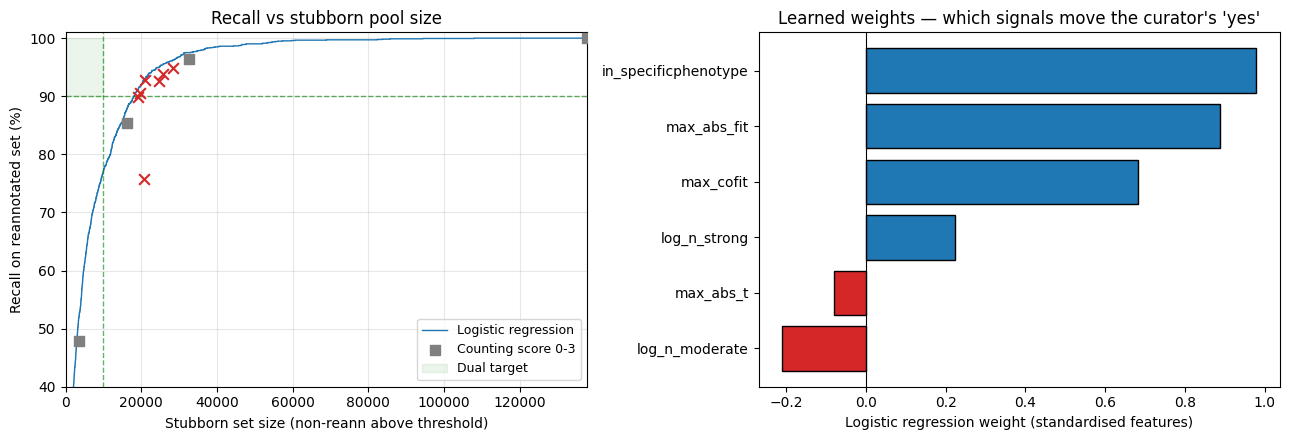

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# (a) Frontier: stubborn (x) vs recall (y) for the logistic scan
ax = axes[0]
ax.plot(logit_ops["stubborn_at_or_above"], logit_ops["recall"] * 100,
        "-", lw=1, color="tab:blue", label="Logistic regression")
# Mark counting-rule points
ax.scatter(count_ops["stubborn_at_or_above"], count_ops["recall"] * 100,
           marker="s", s=60, color="tab:gray", label="Counting score 0-3", zorder=3)
# Mark compound rules
for _, row in rule_df.iterrows():
    ax.scatter(row["stubborn"], row["recall_pct"],
               marker="x", s=60, color="tab:red", zorder=4)
# Target box
ax.axvline(TARGET_MAX_STUBBORN, color="green", ls="--", lw=1, alpha=0.6)
ax.axhline(TARGET_RECALL * 100, color="green", ls="--", lw=1, alpha=0.6)
ax.fill_betweenx([TARGET_RECALL * 100, 100], 0, TARGET_MAX_STUBBORN,
                 color="green", alpha=0.08, label="Dual target")
ax.set_xlabel("Stubborn set size (non-reann above threshold)")
ax.set_ylabel("Recall on reannotated set (%)")
ax.set_title("Recall vs stubborn pool size")
ax.set_xlim(0, max(50000, logit_ops["stubborn_at_or_above"].max()))
ax.set_ylim(40, 101)
ax.legend(loc="lower right", fontsize=9)
ax.grid(alpha=0.3)

# (b) Feature weights
ax = axes[1]
w = weights.sort_values()
colors = ["tab:red" if v < 0 else "tab:blue" for v in w.values]
ax.barh(w.index, w.values, color=colors, edgecolor="black")
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Logistic regression weight (standardised features)")
ax.set_title("Learned weights — which signals move the curator's 'yes'")

plt.tight_layout()
fig_path = FIG_DIR / "fig02_recall_vs_pool_size.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
print(f"Saved {fig_path}")
plt.show()

## 8. Pick the operating point and save the stubborn set

Logic: prefer logistic regression if it hits the dual target; otherwise fall back to
whichever rule is closest to the target. Record which was chosen.

In [9]:
candidates = []
if logit_pick["feasible"]:
    candidates.append(("logit", logit_pick, df["logit_score"].values, float(logit_pick["threshold"])))
# Try compound rules that hit the target
for _, row in rule_df[rule_df["hits_target"]].iterrows():
    mask = rules[row["rule"]]
    candidates.append(("rule:" + row["rule"], {
        "feasible": True,
        "recall": row["recall_pct"] / 100,
        "stubborn_at_or_above": row["stubborn"],
        "pool_size": row["pool"],
        "threshold": np.nan,
    }, mask.values.astype(int), 0.5))

if not candidates:
    # no rule hits target; pick the logistic-frontier point that met recall (best stubborn)
    candidates.append(("logit-best-effort", logit_pick, df["logit_score"].values, float(logit_pick["threshold"])))
    print("WARNING: No classifier hits the dual target; using best-effort logistic threshold.")

# Choose the candidate with smallest stubborn set
best_name, best_pick, best_scores, best_thresh = min(
    candidates, key=lambda c: c[1]["stubborn_at_or_above"]
)
print(f"Chosen classifier: {best_name}")
print(f"  Recall:            {best_pick['recall']*100:.1f}%")
print(f"  Pool size:         {int(best_pick['pool_size']):,}")
print(f"  Stubborn set size: {int(best_pick['stubborn_at_or_above']):,}")
if best_name.startswith("rule:"):
    mask = best_scores == 1
else:
    mask = best_scores >= best_thresh
df["in_candidate_pool"] = mask.astype(int)
df["chosen_score"] = best_scores

Chosen classifier: logit-best-effort
  Recall:            90.1%
  Pool size:         19,689
  Stubborn set size: 18,132


## 9. Annotation-category distribution (descriptive only)

Categorise each gene's existing `gene.desc` into {hypothetical, DUF, vague,
named_enzyme, named_other}. This is **descriptive** — we use it to characterise
what KIND of genes end up in the stubborn set vs. the reannotated set. It is NOT a
filter.

In [10]:
def categorise_desc(desc: str) -> str:
    d = (desc or "").strip().lower()
    if not d or d.startswith("locus ") or d in {"-", ""}:
        return "hypothetical"
    if "hypothetical" in d or "uncharacterized" in d or "unknown function" in d:
        if "duf" in d or "upf" in d:
            return "DUF"
        return "hypothetical"
    if "duf" in d or "upf" in d:
        return "DUF"
    if any(tok in d for tok in ("putative", "predicted", "probable", "possible")):
        return "vague"
    # Named enzyme-like
    enz_tokens = ("ase ", "ase,", "ase/", "ase-", "ligase", "reductase", "transporter",
                  "kinase", "synthase", "dehydrogenase", "permease", "oxidase", "transferase",
                  "hydrolase", "isomerase", "mutase", "polymerase")
    if any(tok in d for tok in enz_tokens) or d.endswith("ase"):
        return "named_enzyme"
    return "named_other"


df["annotation_category"] = df["gene_desc"].astype(str).map(categorise_desc)

# Distribution over reannotated vs stubborn (candidate pool AND not reannotated)
is_stubborn = (df["in_candidate_pool"] == 1) & (df["is_reannotated"] == 0)
reann_cat = df[df["is_reannotated"] == 1]["annotation_category"].value_counts()
stubborn_cat = df[is_stubborn]["annotation_category"].value_counts()

cat_table = pd.DataFrame({
    "reannotated_1729": reann_cat.reindex(["hypothetical", "DUF", "vague", "named_enzyme", "named_other"]).fillna(0).astype(int),
    f"stubborn_{int(is_stubborn.sum())}": stubborn_cat.reindex(["hypothetical", "DUF", "vague", "named_enzyme", "named_other"]).fillna(0).astype(int),
})
cat_table["reann_pct"] = (cat_table["reannotated_1729"] / cat_table["reannotated_1729"].sum() * 100).round(1)
cat_table[f"stubborn_pct"] = (cat_table[f"stubborn_{int(is_stubborn.sum())}"] / cat_table[f"stubborn_{int(is_stubborn.sum())}"].sum() * 100).round(1)
print("Existing annotation category distribution:")
print(cat_table)

Existing annotation category distribution:
                     reannotated_1729  stubborn_18132  reann_pct  stubborn_pct
annotation_category                                                           
hypothetical                      121            2602        7.0          14.4
DUF                                15             119        0.9           0.7
vague                              83            1087        4.8           6.0
named_enzyme                     1360            9332       78.7          51.5
named_other                       150            4992        8.7          27.5


Saved /Users/paramvirdehal/KBase/ke-pangenome-science/projects/fitness_browser_stubborn_set/figures/fig03_annotation_categories.png


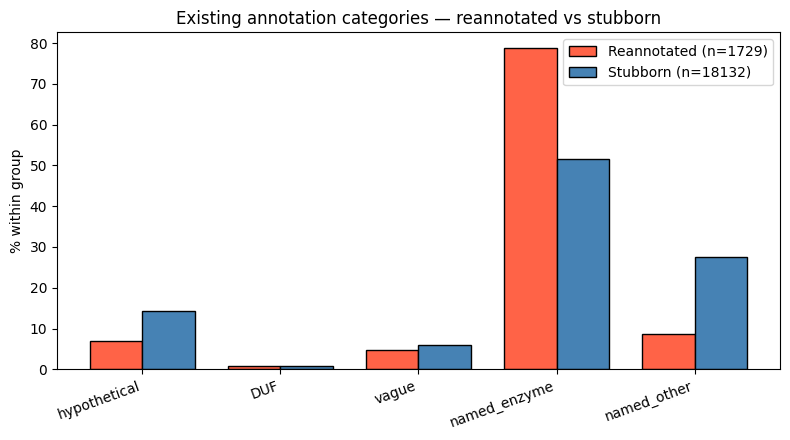

In [11]:
fig, ax = plt.subplots(1, 1, figsize=(8, 4.5))
cats = ["hypothetical", "DUF", "vague", "named_enzyme", "named_other"]
reann_pct = cat_table.loc[cats, "reann_pct"].values
stubborn_pct = cat_table.loc[cats, "stubborn_pct"].values
x = np.arange(len(cats))
w = 0.38
ax.bar(x - w/2, reann_pct, w, label=f"Reannotated (n={int(cat_table['reannotated_1729'].sum())})", color="tomato", edgecolor="black")
ax.bar(x + w/2, stubborn_pct, w, label=f"Stubborn (n={int(cat_table.iloc[:,1].sum())})", color="steelblue", edgecolor="black")
ax.set_xticks(x)
ax.set_xticklabels(cats, rotation=20, ha="right")
ax.set_ylabel("% within group")
ax.set_title("Existing annotation categories — reannotated vs stubborn")
ax.legend()
plt.tight_layout()
fig_path = FIG_DIR / "fig03_annotation_categories.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
print(f"Saved {fig_path}")
plt.show()

## 10. Save artifacts

In [12]:
stubborn_df = df[is_stubborn].copy()
stubborn_out = DATA_DIR / "stubborn_set_chosen.parquet"
stubborn_df.to_parquet(stubborn_out, index=False)
print(f"Wrote {stubborn_out}  ({len(stubborn_df):,} rows)")

# Comprehensive calibration summary across all three approaches
summary_rows = []
for _, row in count_ops.iterrows():
    summary_rows.append({
        "classifier": "counting",
        "threshold": float(row["threshold"]),
        "recall_pct": round(row["recall"] * 100, 2),
        "pool_size": int(row["pool_size"]),
        "stubborn_size": int(row["stubborn_at_or_above"]),
        "hits_target": (row["recall"] >= TARGET_RECALL) and (row["stubborn_at_or_above"] <= TARGET_MAX_STUBBORN),
    })
# Sample the logistic frontier (10%, 20%, ..., at tick thresholds + chosen)
for r_target in [0.80, 0.85, 0.90, 0.92, 0.95, 0.98, 1.00]:
    eligible = logit_ops[logit_ops["recall"] >= r_target]
    if len(eligible):
        row = eligible.sort_values("stubborn_at_or_above").iloc[0]
        summary_rows.append({
            "classifier": "logistic",
            "threshold": float(row["threshold"]),
            "recall_pct": round(row["recall"] * 100, 2),
            "pool_size": int(row["pool_size"]),
            "stubborn_size": int(row["stubborn_at_or_above"]),
            "hits_target": (row["recall"] >= TARGET_RECALL) and (row["stubborn_at_or_above"] <= TARGET_MAX_STUBBORN),
        })
for _, row in rule_df.iterrows():
    summary_rows.append({
        "classifier": "compound",
        "threshold": row["rule"],
        "recall_pct": row["recall_pct"],
        "pool_size": int(row["pool"]),
        "stubborn_size": int(row["stubborn"]),
        "hits_target": bool(row["hits_target"]),
    })
summary_df = pd.DataFrame(summary_rows)
summary_out = DATA_DIR / "threshold_calibration_summary.csv"
summary_df.to_csv(summary_out, index=False)
print(f"Wrote {summary_out}")

# Record the chosen classifier in a small json
import json
chosen_out = DATA_DIR / "chosen_classifier.json"
with open(chosen_out, "w") as f:
    json.dump({
        "classifier": best_name,
        "recall_pct": round(best_pick["recall"] * 100, 2),
        "pool_size": int(best_pick["pool_size"]),
        "stubborn_size": int(best_pick["stubborn_at_or_above"]),
        "threshold": None if np.isnan(best_thresh) else float(best_thresh),
        "target_recall_pct": TARGET_RECALL * 100,
        "target_max_stubborn": TARGET_MAX_STUBBORN,
    }, f, indent=2)
print(f"Wrote {chosen_out}")

Wrote /Users/paramvirdehal/KBase/ke-pangenome-science/projects/fitness_browser_stubborn_set/data/stubborn_set_chosen.parquet  (18,132 rows)
Wrote /Users/paramvirdehal/KBase/ke-pangenome-science/projects/fitness_browser_stubborn_set/data/threshold_calibration_summary.csv
Wrote /Users/paramvirdehal/KBase/ke-pangenome-science/projects/fitness_browser_stubborn_set/data/chosen_classifier.json


## 11. Takeaways

- We fit three classifiers (counting baseline, logistic regression, hand-tuned
  compound rules) on the same 6 evidence features.
- The chosen classifier is the one meeting the dual target (≥90% recall AND <10K
  stubborn) with the smallest stubborn set. If no classifier hits both, we record
  the tradeoff frontier and pick the best-effort point.
- NB02 will take the stubborn set forward — compute secondary evidence (conserved
  cofit, ortholog phenotype conservation, informative domain, KEGG KO description,
  SEED, MetaCyc via `metacycpathwayreaction`) and keep the annotation-category tag
  for the NB03 contingency grid.